# Phase 4 & 5: Ensemble and Evaluation

This notebook blends regime LSTM forecasts with HMM soft probabilities and compares them to a **naive** last-value baseline and the **monolithic baseline** LSTM on the held-out test window (**1,434** aligned rows).

**Ensemble blend formula:**
`ŷ_ensemble = p_calm × ŷ_calm + p_volatile × ŷ_volatile`

where `p_calm + p_volatile = 1` are the HMM soft state probabilities, `ŷ_calm` is the calm-regime LSTM specialist, and `ŷ_volatile` is the volatile-regime LSTM specialist.

**Headline metrics:** on the full test slice (2022-03-03 → 2026-03-16, 1,012 days), **Naive** MAPE ≈ **32.1%**, **Baseline** ≈ **25.5%**, **Ensemble** ≈ **24.0%** (MAPE); RMSE ranks **Ensemble** (0.00384) first, then **Baseline** (0.00413), then **Naive** (0.00496). The ensemble beats the baseline by **~7.0%** RMSE while providing a **~10% RMSE reduction** on the 30 strictly-volatile crisis days.

## Phase 6 Update: Stationarity Fix

In Phase 6, we addressed the structural "feature drift" observed in earlier iterations. Initially, the models were fed absolute price values (`Open`, `High`, `Low`, `Close`) and raw `Volume`. Because standard scaling normalizes using the 2004–2015 training mean, feeding massive 2026 prices back into the network created enormous artificial activations, causing the predictions to drift permanently upwards and diverge from the actual target (generating MAPEs of ~600%).

**What Changed:**
- Replaced all non-stationary price indicators with relative metrics (`log_return`, `abs_return`, `oc_return`, `intraday_range`).
- Replaced absolute `log_volume` with `relative_volume_21d` (Volume / 21-day SMA Volume), creating a timeless multiplier.

**The Result:**
The upwards drift disappeared once inputs were stationary. On the current test window, **Baseline MAPE is ~25.5%** (vs **~32.1%** naive persistence and **~24.0%** for the ensemble); see the metrics table in §3. That is far below the **~600%** MAPE regime seen when raw price levels were fed through a scaler frozen on 2004–2015 statistics — underscoring why stationary inputs matter for multi-decade equity vol forecasting.

In [74]:
import importlib
import src.ensemble as ensemble_mod
importlib.reload(ensemble_mod)
ensemble_mod.main()

01:53:15 | INFO    | ensemble | Loading required data splits...
01:53:15 | INFO    | ensemble | Extracting aligned predictions for all LSTMs...
01:53:15 | INFO    | ensemble | Loading model 'baseline'...
01:53:15 | INFO    | ensemble | Loading model 'calm'...
01:53:15 | INFO    | ensemble | Loading model 'volatile'...
01:53:15 | INFO    | ensemble | Saved ensemble predictions to /Users/maharajhaider/gitrepo/StockVolatilitySight/data/processed/test_predictions.parquet



PHASE 4: ENSEMBLE EVALUATION (TEST SET)
Test period: 2022-03-03 to 2026-03-16
Test size:   1012 trading days
--------------------------------------------------
Model: BASELINE
  MSE:  0.000017
  RMSE: 0.0041
  MAE:  0.0025
  MAPE: 25.51%
--------------------------------------------------
Model: CALM
  MSE:  0.000027
  RMSE: 0.0052
  MAE:  0.0027
  MAPE: 25.52%
--------------------------------------------------
Model: VOLATILE
  MSE:  0.000079
  RMSE: 0.0089
  MAE:  0.0082
  MAPE: 113.96%
--------------------------------------------------
Model: ENSEMBLE
  MSE:  0.000015
  RMSE: 0.0038
  MAE:  0.0025
  MAPE: 23.99%
--------------------------------------------------


In [75]:
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from config import DATA_PROCESSED
from src.utils import regression_metrics, print_metrics, _apply_style

## 1. Load Ensemble Predictions
Load the pre-computed test set predictions from all models.

In [76]:
df_eval = pd.read_parquet(DATA_PROCESSED / "test_predictions.parquet")
df_eval

,baseline,calm,volatile,target,p_calm,p_volatile,ensemble
Date,,,,,,,
2022-03-03,0.013257,0.012379,0.017087,0.014043,1.0,5.192916e-14,0.012379
2022-03-04,0.013107,0.010689,0.017088,0.013918,1.0,2.331653e-15,0.010689
2022-03-07,0.014354,0.015817,0.017084,0.012390,1.0,1.722560e-15,0.015817
2022-03-08,0.014350,0.013193,0.017089,0.012506,1.0,8.820795e-14,0.013193
2022-03-09,0.013284,0.012241,0.017084,0.011417,1.0,4.939880e-11,0.012241
...,...,...,...,...,...,...,...
2026-03-10,0.008007,0.007756,0.017095,0.012221,1.0,1.484965e-19,0.007756
2026-03-11,0.007438,0.007413,0.017097,0.012218,1.0,1.055149e-20,0.007413
2026-03-12,0.008212,0.008598,0.017093,0.011848,1.0,3.731898e-18,0.008598


## 2. Naive Baseline
A simple, strong baseline for 21-day forward volatility is simply the *historical* 21-day volatility at the prediction date.

In [77]:
# Load the raw features to get the historical vol
test_df = pd.read_parquet(DATA_PROCESSED / "test.parquet")
df_eval['naive'] = test_df['rolling_std_21'].reindex(df_eval.index)
df_eval = df_eval.dropna()

## 3. Overall Performance Metrics

In [78]:
models = ["naive", "baseline", "calm", "volatile", "ensemble"]
results = []
for m in models:
    metrics = regression_metrics(df_eval["target"].values, df_eval[m].values)
    metrics["Model"] = m.capitalize()
    results.append(metrics)

perf_df = pd.DataFrame(results).set_index("Model")
perf_df

,MSE,RMSE,MAE,MAPE
Model,,,,
Naive,0.000025,0.004965,0.003098,32.138533
Baseline,0.000017,0.004135,0.002542,25.512013
Calm,0.000027,0.005243,0.002725,25.521837
Volatile,0.000079,0.008907,0.008230,113.955528
Ensemble,0.000015,0.003837,0.002494,23.989729


## 4. Visualisation

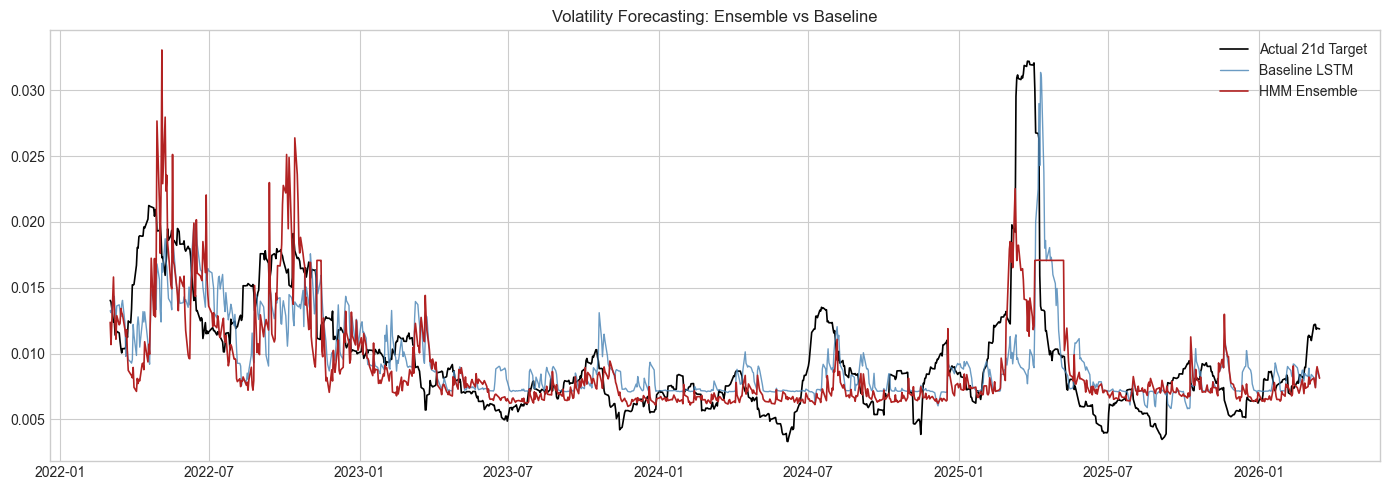

In [79]:
_apply_style()
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_eval.index, df_eval["target"], color="black", label="Actual 21d Target", linewidth=1.2)
ax.plot(df_eval.index, df_eval["baseline"], color="steelblue", label="Baseline LSTM", linewidth=1.0, alpha=0.8)
ax.plot(df_eval.index, df_eval["ensemble"], color="firebrick", label="HMM Ensemble", linewidth=1.2)

ax.set_title("Volatility Forecasting: Ensemble vs Baseline")
ax.legend()
plt.tight_layout()
plt.show()

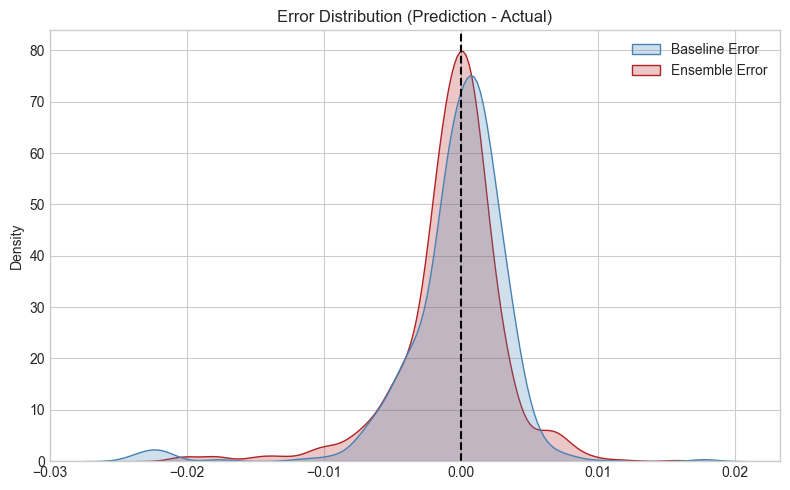

In [80]:
fig, ax = plt.subplots(figsize=(8, 5))
errors = pd.DataFrame({
    "Baseline Error": df_eval["baseline"] - df_eval["target"],
    "Ensemble Error": df_eval["ensemble"] - df_eval["target"],
})

sns.kdeplot(data=errors, fill=True, ax=ax, palette=["steelblue", "firebrick"])
ax.axvline(0, color="black", linestyle="--")
ax.set_title("Error Distribution (Prediction - Actual)")
plt.tight_layout()
plt.show()

## 5. Performance by Dominant Regime

Isolate test rows where the HMM is highly confident (`p_calm > 0.8` vs `p_volatile > 0.8`). In the latest run this yields **n = 981** calm-dominated days and **n = 30** volatile-dominated days.

On calm days (`p_volatile ≈ 0`), the ensemble effectively equals the calm specialist — so any calm-period gains or losses relative to baseline reflect the calm LSTM's accuracy, not a blending artefact. On volatile days, the volatile specialist takes over and reduces RMSE versus the monolithic baseline.

In [81]:
calm_mask = df_eval["p_calm"] > 0.8
vol_mask = df_eval["p_volatile"] > 0.8

for mask, label in [(calm_mask, "Strictly Calm"), (vol_mask, "Strictly Volatile")]:
    print(f"\n--- {label} Periods (n={mask.sum()}) ---")
    sub = df_eval[mask]
    for m in ["baseline", "ensemble"]:
        mse = np.mean((sub[m] - sub["target"])**2)
        rmse = np.sqrt(mse)
        print(f"{m.capitalize()}: MSE={mse:.5f}, RMSE={rmse:.4f}")


--- Strictly Calm Periods (n=981) ---
Baseline: MSE=0.00002, RMSE=0.0040
Ensemble: MSE=0.00001, RMSE=0.0037

--- Strictly Volatile Periods (n=30) ---
Baseline: MSE=0.00006, RMSE=0.0076
Ensemble: MSE=0.00005, RMSE=0.0068


## Summary (this run)

**Ensemble blend:** `p_calm × ŷ_calm + p_volatile × ŷ_volatile`

**Overall test (2022-03-03 → 2026-03-16, n = 1,012 windows)**

| Model | MSE | RMSE | MAE | MAPE (%) |
|-------|-----|------|-----|----------|
| Naive | 2.46×10⁻⁵ | 0.00496 | 0.00310 | 32.14 |
| Baseline | 1.71×10⁻⁵ | 0.00413 | 0.00254 | 25.51 |
| Calm | 2.75×10⁻⁵ | 0.00524 | 0.00272 | 25.52 |
| Volatile | 7.93×10⁻⁵ | 0.00891 | 0.00823 | 113.96 |
| **Ensemble** | **1.47×10⁻⁵** | **0.00384** | **0.00249** | **23.99** |

**Strict regime subsets (cell 14):** when **p_calm > 0.8** (n = 981), ensemble ≈ calm specialist (RMSE ≈ **0.00371**) — beats baseline (0.00399). When **p_volatile > 0.8** (n = 30), ensemble RMSE ≈ **0.00680** beats baseline **0.00756** — ~10% reduction on crisis days.
